In [2]:
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
PKLs = []
PKL_titles = []
for file in os.listdir("./"):
    if file.endswith(".pkl"):
        PKLs.append(pickle.load(open(file, "rb")))
        PKL_titles.append(str(file))
n = len(PKLs)

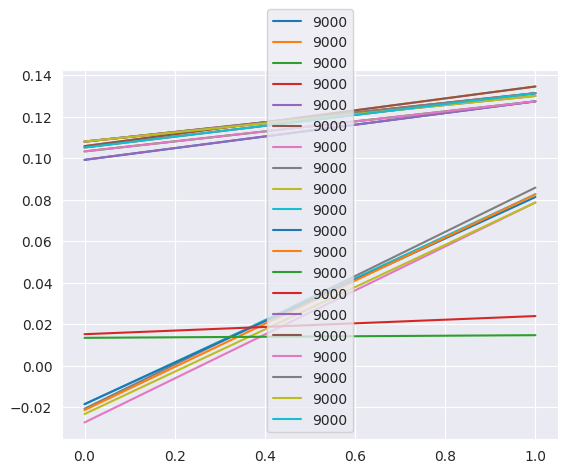

In [3]:
for idx in range(n):
    plt.plot(np.mean(PKLs[idx]['res'][0][-1], axis=[0, 1]).T, label=np.prod(PKLs[idx]['res'][0][-1].shape[:2]))
plt.legend()

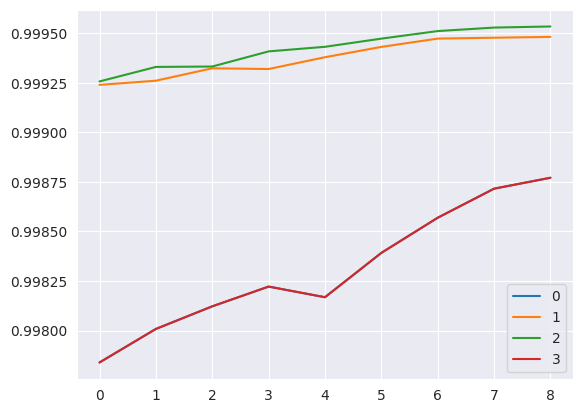

In [4]:
for idx in range(n):
    weights = np.exp(PKLs[idx]['res'][1][:,:,].reshape((*PKLs[idx]['res'][1].shape[:2], -1)))
    num_particles = weights.shape[-1]
    plt.plot(np.mean(1/np.sum(np.square(weights), axis=-1).T/num_particles, axis=-1), label=idx)
plt.legend()

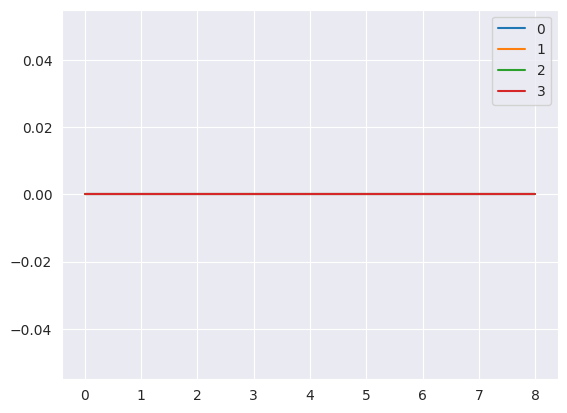

In [5]:
for idx in range(n):
    plt.plot(PKLs[idx]['res'][3][0].mean(axis=[1, 2]), label=idx)
plt.legend()

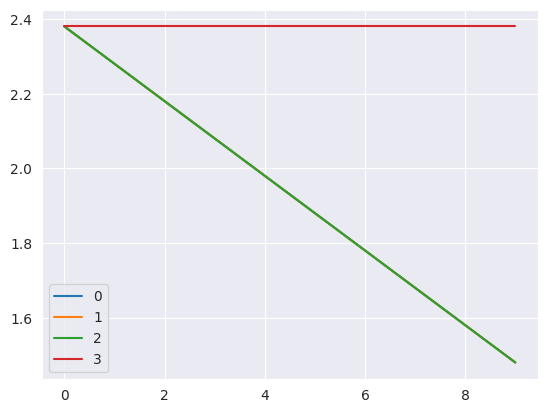

In [6]:
for idx in range(n):
    plt.plot(PKLs[idx]['res'][2][...,0].mean(axis=0), label=idx)
plt.legend()

/tmp/ipykernel_55050/77087747.py:2: RuntimeWarning: Mean of empty slice.
  plt.plot(np.sum(np.square(np.diff(PKLs[idx]['res'][0], axis=-2, n=5)), axis=-1).mean(axis=-1).mean(axis=-1).mean(axis=0)[1:], label=idx)
/home/yvann/adaptative_smc_tempering/my-venv/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


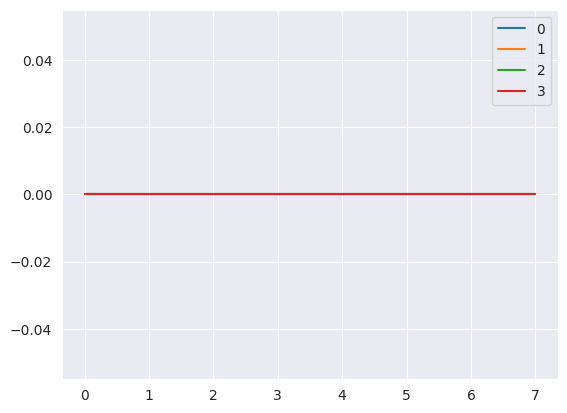

In [7]:
for idx in range(n):
    plt.plot(np.sum(np.square(np.diff(PKLs[idx]['res'][0], axis=-2, n=5)), axis=-1).mean(axis=-1).mean(axis=-1).mean(axis=0)[1:], label=idx)
plt.legend()

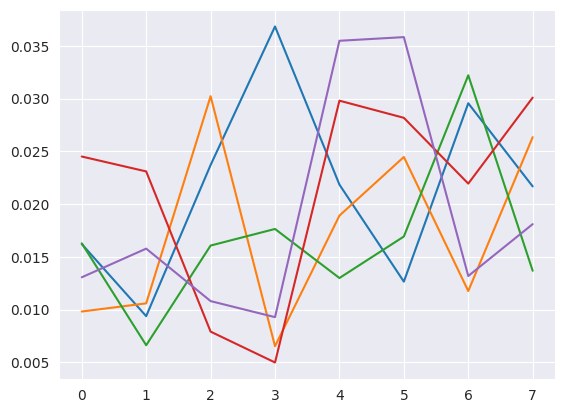

In [8]:
import jax
import jax.numpy as jnp
is_weights = jnp.exp(PKLs[0]['res'][4])
is_weights = is_weights.reshape(is_weights.shape[:2] + (-1,))
is_weights_shape = is_weights.shape
is_weights = is_weights.reshape(-1, is_weights.shape[-1])
var_over_mean_sq = jax.vmap(lambda s: jnp.var(s)/jnp.mean(s)**2, in_axes=(0))(is_weights)
var_over_mean_sq = var_over_mean_sq.reshape(is_weights_shape[:2])
plt.plot(var_over_mean_sq.T)

In [17]:
t = PKLs[0]['res'][0][:,-1].reshape(5, 6000, 2)

In [20]:
t.std(axis=1)

Array([[0.8010515 , 0.9449333 ],
       [0.89503694, 0.92496437],
       [0.91653776, 0.9336953 ],
       [0.82355976, 0.9749086 ],
       [0.929272  , 0.88048685]], dtype=float32)